# Prepare

Run `generate_grid_graph_json.py` on whatever configuration you please

# Sampling
Run Julia code to sample partitions, e.g.
```
./sampling/run.sh --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1
```
On a Windows machine through Powershell, something like the following might work:
```
julia --project="sampling/runCycleWalkEnv" sampling/run_cyclewalk.jl --map-file data/graph/grid_graph_5_by_5.json --output-file local/output/grid5x5/atlas.jsonl.gz --cycle-walk-steps 1e5 --pop-dev 0.1 --rng-seed 42
```

# Analysis

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from data import generate_grid_shape
from hierachical import HClusters
from sample import SampleProcessor
from utils import (
    plot_district,
    plot_plan,
    plot_words_centroids,
    plot_words_list,
    plot_district_by_uid,
)
from word import PlanWordBuilder, WordStat
from scipy.cluster.hierarchy import dendrogram, linkage

square_side = 100
num_districts = 5

PRECINCT_FN = "data/graph/grid_graph_100_by_100_5.json"
SAMPLE_FN = "local/output/grid100x100-5/atlas.jsonl.gz"
OUT_DIR = "local/output/grid100x100-5/processed"
gdf = generate_grid_shape(square_side)

is_huge = True if square_side > 4 else False

In [16]:
sp = SampleProcessor(PRECINCT_FN, OUT_DIR)
# run this once to process samples and dump artifacts for future use
sp.clean()
sp.process_samples([SAMPLE_FN], max_length=1000, min_step=100)
sp.load_processed()

Reading local\output\grid100x100-5\atlas.jsonl.gz


plans: 100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2686.36it/s]


We give each district a unique `district_uid'. Districts are stored via the precincts that they contain (i.e. as an array of ints).

In [17]:
sp.df_districts.head()

,district_str,district_uid
0,0.1.2.3.4.5.6.7.8.9.10.11.12.13.14.15.16.17.18...,0
1,249.250.251.348.349.350.351.352.448.449.450.45...,1
2,57.58.59.60.61.62.63.64.65.66.67.68.69.70.71.7...,2
3,4696.4697.4698.4796.4797.4798.4799.4892.4893.4...,3
4,5249.5250.5251.5349.5350.5351.5352.5447.5448.5...,4


Each plan is stored using `district_uid's and is given a 'plan_id'

In [18]:
sp.df_plans.head()

,step,plan_id,sample_tag,plan,plan_str
0,1000,0,atlas,"[0, 1, 2, 3, 4]",0.1.2.3.4
1,2000,1,atlas,"[5, 6, 7, 8, 9]",5.6.7.8.9
2,3000,2,atlas,"[10, 11, 12, 13, 14]",10.11.12.13.14
3,4000,3,atlas,"[15, 16, 17, 18, 19]",15.16.17.18.19
4,5000,4,atlas,"[20, 21, 22, 23, 24]",20.21.22.23.24


We visualize the first sampled plan and its first district

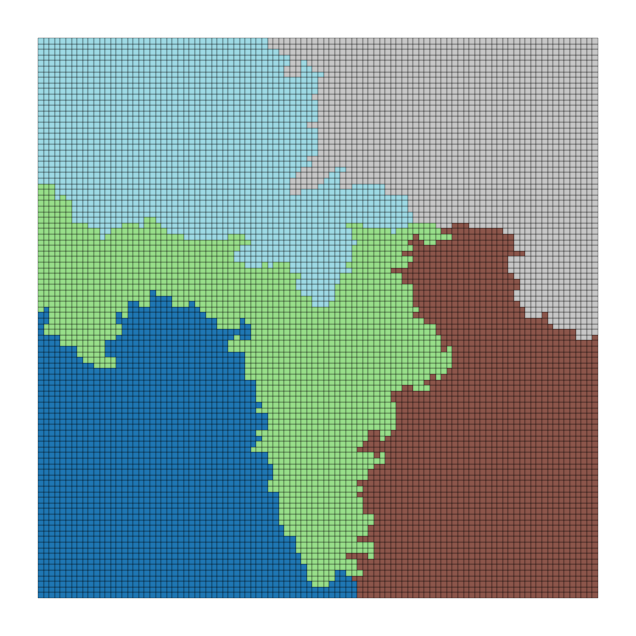

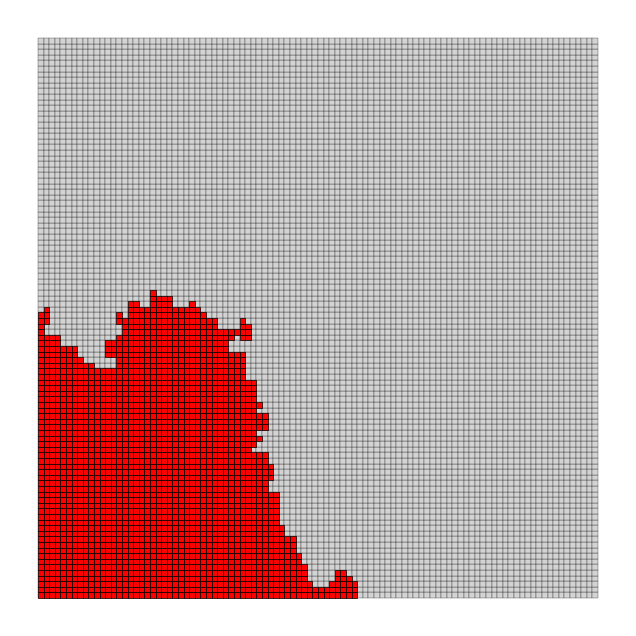

In [19]:
plan = sp.df_plans.iloc[0].plan
labels = sp.decode_plan_vector(plan)
plot_plan(gdf, labels)
plt.show()

district = sp.decode_district(plan[0])
plot_district(gdf, district)
plt.show()

Next, we run hcc and infer clusters at a given number of letters.

In [20]:
sp.load_distance_matrix()
sp.ensure_linkage()

num_letters = num_districts
hc = HClusters(sp)
hc.update_clusters(num_letters)
hc.kcentroids()

  2%|█▊                                                                                           | 1/50 [00:00<00:24,  2.04it/s]

epoch 0: rel_improvement = 0.031140160997278486


  2%|█▊                                                                                           | 1/50 [00:00<00:46,  1.04it/s]


We visualize some letters 

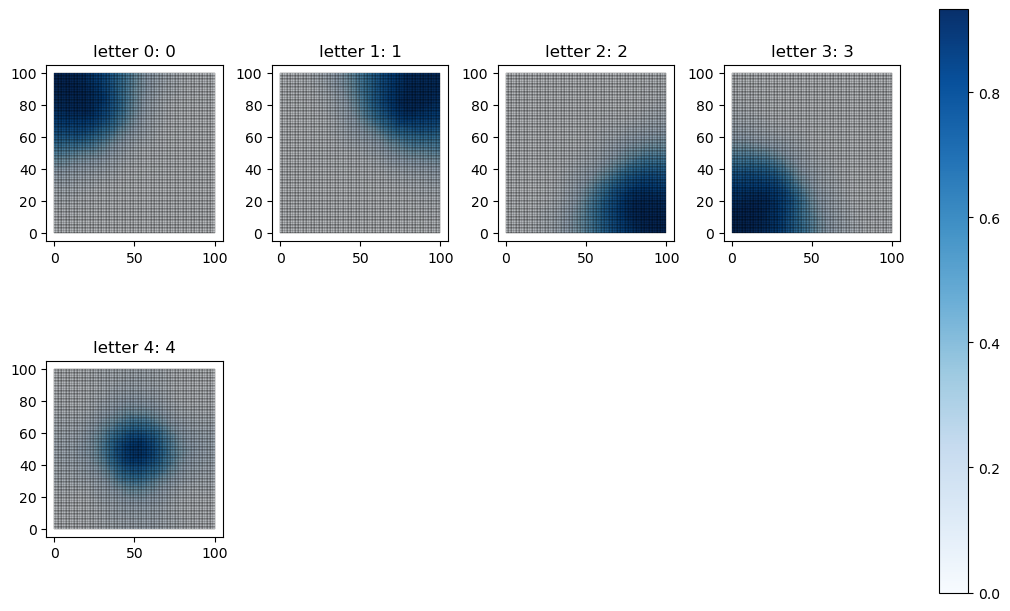

In [21]:
letters = list(range(num_letters))
plot_words_list(gdf, hc.cluster_densities, letters, cols=4, figsize=(10, 6))
plt.show()

We then use the letters to construct words via beam search with a prescribed `word_degree'

In [22]:
pw = PlanWordBuilder(sp, hc, word_degree=10, verbose=True, centroid_norm="l1").build()
pw.df_words.head()

Enumerating words: 100%|███████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 9056.43it/s]


,plan_uid,plan,word,distance,min_distance,plan_str,word_str,word_uid
0,0,"[0, 1, 2, 3, 4]","[0, 1, 2, 3, 4]",3521.0,3521.0,0.1.2.3.4,0.1.2.3.4,17
1,0,"[0, 1, 2, 3, 4]","[0, 0, 1, 2, 3]",5219.0,3521.0,0.1.2.3.4,0.0.1.2.3,2
2,0,"[0, 1, 2, 3, 4]","[1, 2, 3, 4, 4]",5355.0,3521.0,0.1.2.3.4,1.2.3.4.4,37
3,0,"[0, 1, 2, 3, 4]","[0, 1, 2, 2, 3]",5797.0,3521.0,0.1.2.3.4,0.1.2.2.3,14
4,0,"[0, 1, 2, 3, 4]","[0, 1, 2, 3, 3]",5888.0,3521.0,0.1.2.3.4,0.1.2.3.3,16


We compute stationary distribution under some POU (controlled by temperature).

In [23]:
ws = WordStat(pw, temp=0.0, verbose=False)
df_top = ws.stationary_table().head(3).reset_index(drop=True)
df_top

,word_uid,word_str,word,stationary
0,17,0.1.2.3.4,"[0, 1, 2, 3, 4]",0.107694
1,14,0.1.2.2.3,"[0, 1, 2, 2, 3]",0.091761
2,10,0.1.1.2.3,"[0, 1, 1, 2, 3]",0.089861


This is the flux matrix

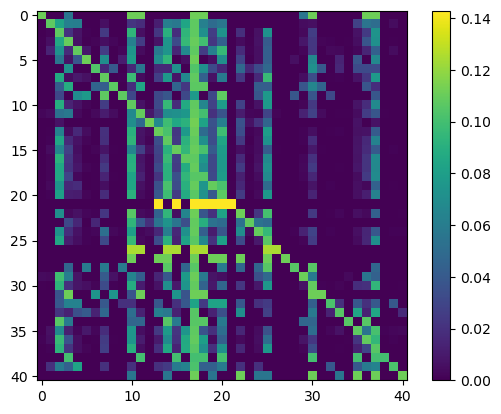

In [24]:
plt.imshow(ws.flux_matrix())
plt.colorbar()

These are some most frequent words under the stationary distribution

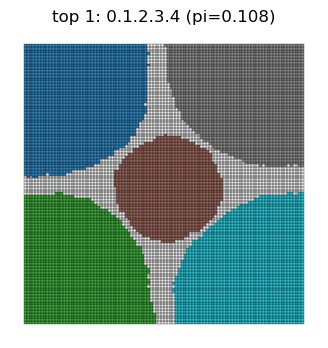

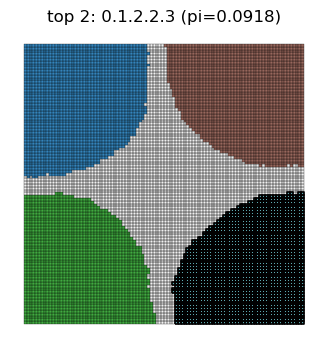

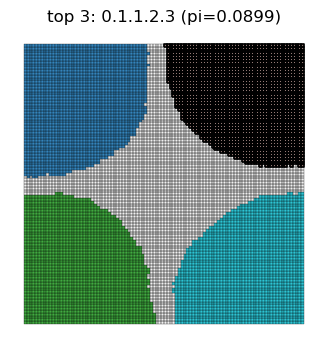

In [25]:
for i, row in df_top.iterrows():
    fig, ax = plot_words_centroids(
        gdf, hc.cluster_densities, row.word, ltr=True, figsize=(4, 4)
    )
    ax.set_title(f"top {i + 1}: {row.word_str} (pi={row.stationary:.3g})")
    plt.show()

Visualize dendrogram from sp linkage

In [26]:
def plot_dendrogram_from_linkage(Z, no_labels=False):
    fig, ax = plt.subplots(figsize=(12, 6))
    dendrogram(Z, ax=ax, no_labels=no_labels)
    ax.set_xlabel("District UID")
    ax.set_ylabel("Merge distance")
    ax.set_title("District clustering dendrogram")
    plt.tight_layout()
    plt.show()

if not is_huge:
    plot_dendrogram_from_linkage(np.load(sp.paths.linkage).astype(np.float64))

In [27]:
# Code by Claude Sonnet 4.6

Z = np.load(sp.paths.linkage).astype(np.float64)
n = int(Z.shape[0] + 1)

from collections import defaultdict

node_to_cluster = {}  # leaf -> cluster id
cluster_members = defaultdict(set)
cluster_first_dist = {}  # cluster id -> distance at which it was first formed
cluster_counter = 0

for i, (a, b, dist, size) in enumerate(Z):
    a, b = int(a), int(b)
    new_node = n + i

    a_leaves = cluster_members[a] if a >= n else {a}
    b_leaves = cluster_members[b] if b >= n else {b}
    cluster_members[new_node] = a_leaves | b_leaves

    a_assigned_leaves = {leaf for leaf in a_leaves if leaf in node_to_cluster}
    b_assigned_leaves = {leaf for leaf in b_leaves if leaf in node_to_cluster}
    a_assigned = len(a_assigned_leaves) > 0
    b_assigned = len(b_assigned_leaves) > 0

    if not a_assigned and not b_assigned:
        cid = cluster_counter
        cluster_counter += 1
        cluster_first_dist[cid] = dist
        for leaf in a_leaves | b_leaves:
            node_to_cluster[leaf] = cid
    elif a_assigned and not b_assigned:
        cid = node_to_cluster[next(iter(a_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid
    elif b_assigned and not a_assigned:
        cid = node_to_cluster[next(iter(b_assigned_leaves))]
        if dist == cluster_first_dist[cid]:
            for leaf in a_leaves | b_leaves:
                node_to_cluster[leaf] = cid

# Collect clusters
lowest_level = defaultdict(set)
for leaf, cid in node_to_cluster.items():
    lowest_level[cid].add(leaf)

singletons = [{i} for i in range(n) if i not in node_to_cluster]
all_lowest_clusters = list(lowest_level.values()) + singletons

print(f"{len(all_lowest_clusters)} total lowest-level clusters ({len(singletons)} singletons)")
for c in sorted(all_lowest_clusters, key=len, reverse=True):
    print(sorted(c))

3046 total lowest-level clusters (1092 singletons)
[4953, 4958]
[3039, 4882]
[725, 1252]
[3555, 3560]
[162, 2420]
[712, 717]
[2532, 2629]
[2000, 3320]
[23, 349]
[1619, 1624]
[1847, 2828]
[1757, 4105]
[3805, 3930]
[14, 412]
[959, 1592]
[1053, 2671]
[3408, 3611]
[1776, 1964]
[950, 955]
[1142, 4368]
[1261, 4975]
[341, 376]
[211, 1542]
[2597, 3398]
[173, 2289]
[3250, 4324]
[2259, 4224]
[2891, 3353]
[2173, 4077]
[1515, 4095]
[322, 2082]
[333, 3707]
[3095, 3813]
[3403, 4319]
[3274, 3279]
[454, 2061]
[2586, 2814]
[1156, 1332]
[3718, 4581]
[1440, 2607]
[1852, 2818]
[431, 3575]
[2673, 4814]
[3503, 4849]
[2095, 2263]
[1765, 4485]
[21, 3029]
[747, 4279]
[3988, 4307]
[233, 2582]
[1052, 2628]
[3008, 3521]
[1711, 3692]
[2563, 4185]
[128, 4518]
[426, 3176]
[320, 4856]
[1207, 1212]
[1001, 2768]
[4228, 4238]
[2096, 2592]
[119, 810]
[757, 2647]
[2600, 3431]
[947, 952]
[67, 3444]
[1462, 2513]
[449, 2845]
[1176, 1181]
[1364, 4619]
[3777, 4703]
[4736, 4852]
[154, 3866]
[1131, 4898]
[17, 1286]
[1057, 1062]


In [28]:
if not is_huge:
    all_lowest_clusters = [sorted(c) for c in all_lowest_clusters]
    largest_LL_cluster_size = max([len(c) for c in all_lowest_clusters])
    n_LL_clusters = len(all_lowest_clusters)
    
    fig, axes = plt.subplots(n_LL_clusters, largest_LL_cluster_size)
    
    for i in range(n_LL_clusters):
        for j in range(len(all_lowest_clusters[i])):
            plot_district_by_uid(gdf, sp.df_districts, all_lowest_clusters[i][j], ax=axes[i][j])
            axes[i][j].text(
                -0.05, 0.5, str(all_lowest_clusters[i][j]),
                transform=axes[i][j].transAxes,
                fontsize=7, va="center", ha="right"
            )
        for j in range(len(all_lowest_clusters[i]), largest_LL_cluster_size):
            plot_district(gdf, np.zeros(len(gdf), dtype=bool), ax=axes[i][j])
    plt.tight_layout()
    plt.show()